# Decision Tree — CIC-IDS 2018 | Wrapper Method (RFE)

**Dataset:** CIC-IDS 2018 (balanced parquet)  
**Cross-evaluation:** CIC-IDS 2017 (natural distribution)  
**Feature Selection:** Wrapper method — Recursive Feature Elimination (RFE)  
**Pipeline:** Load data → Column overview → Group labels → Clean → Encode → Split → RFE sweep → Rank features → Evaluate → Cross-dataset (Method 1)

> Note: Decision Tree does not require feature scaling; raw features are passed directly to RFE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/cic2018_balanced_dataset_standardized.parquet"
raw_data = pd.read_parquet(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,Protocol,Timestamp,Dst Port,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Packets/s,Bwd Packets/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Header Length.1,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6.0,14/02/2018 08:53:42,60556.0,157.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,12738.853516,157.0,0.000000e+00,157.0,157.0,157.0,157.00,0.0,157.0,157.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,12738.853516,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.000000,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,255.0,-1.0,0.0,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
1,6.0,14/02/2018 10:38:48,80.0,53993792.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.037041,53993792.0,0.000000e+00,53993792.0,53993792.0,53993792.0,53993792.00,0.0,53993792.0,53993792.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,0.037041,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000,0.000000,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,279.0,-1.0,0.0,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
2,6.0,14/02/2018 09:38:17,443.0,61113950.0,16.0,14.0,1578.0,2749.0,538.0,0.0,98.625,178.133987,1116.0,0.0,196.357147,371.917389,70.802162,0.490886,2107377.5,4.100328e+06,10012729.0,19.0,61113950.0,4074263.25,5012311.5,10024262.0,315.0,61102345.0,4700180.5,5125839.0,10024270.0,284.0,0.0,0.0,0.0,0.0,332.0,364.0,0.261806,0.229080,0.0,1116.0,139.580643,280.809509,78853.984375,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,144.233337,98.625,196.357147,332.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,1578.0,14.0,2749.0,8192.0,131.0,11.0,20.0,83368.664062,175935.75,442496.0,11484.0,9992150.0,33221.078125,10012729.0,9924726.0,Benign
3,17.0,14/02/2018 11:19:03,53.0,79651.0,1.0,1.0,35.0,51.0,35.0,35.0,35.000,0.000000,51.0,51.0,51.000000,0.000000,1079.710205,25.109541,79651.0,0.000000e+00,79651.0,79651.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,12.554770,12.554770,35.0,51.0,40.333332,9.237604,85.333336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,60.500000,35.000,51.000000,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35.0,1.0,51.0,-1.0,-1.0,0.0,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
4,17.0,14/02/2018 09:19:31,53.0,12230.0,1.0,1.0,55.0,83.0,55.0,55.0,55.000,0.000000,83.0,83.0,83.000000,0.000000,11283.728516,163.532303,12230.0,0.000000e+00,12230.0,12230.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,81.766151,81.766151,55.0,83.0,64.333336,16.165808,261.333344,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,96.500000,55.000,83.000000,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,55.0,1.0,83.0,-1.0,-1.0,0.0,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263642,6.0,23/02/2018 03:17:24,80.0,46.0,2.0

## 1. Load Dataset

Loads the CIC-IDS 2018 balanced dataset from a Parquet file. The raw DataFrame is displayed to confirm the number of rows, columns, and a sample of the feature space.

In [2]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values,
})
summary


,Column,Data Type,Missing Values,Unique Values
0,Protocol,float32,0,3
1,Timestamp,string[python],0,59810
2,Dst Port,float64,0,9835
3,Flow Duration,float64,0,134714
4,Tot Fwd Pkts,float64,0,1921
...,...,...,...,...
76,Idle Mean,float64,0,28581
77,Idle Std,float32,0,11496
78,Idle Max,float64,0,26655
79,Idle Min,float64,0,27394


## 2. Dataset Structure Overview

Produces a summary table of column names, data types, missing value counts, and the number of unique values per column. Useful for spotting high-cardinality or incomplete features early.

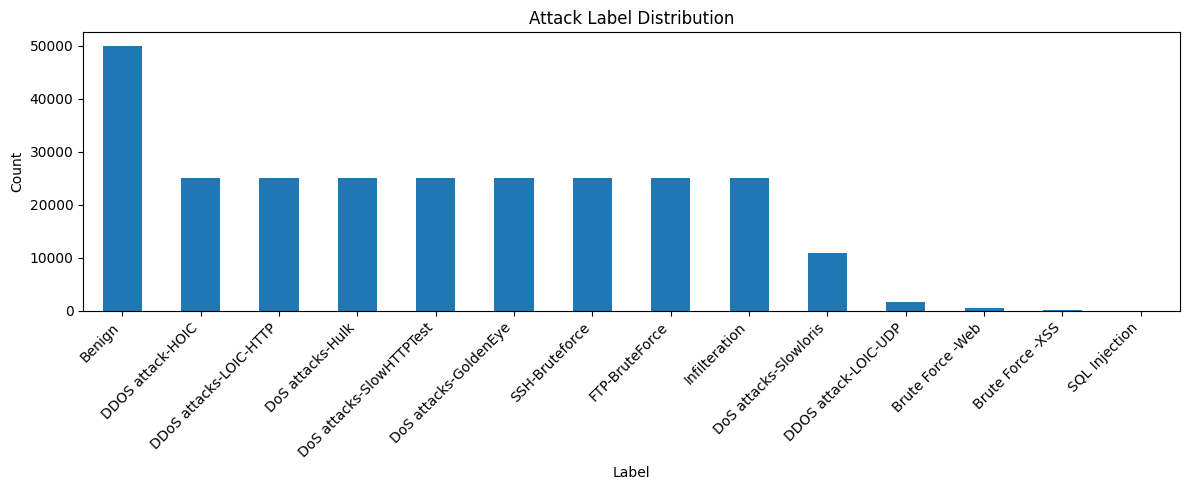

In [3]:
# Label distribution
label_counts = df['Label'].value_counts()

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## 3. Label Distribution

Displays a bar chart of raw attack label counts in the dataset before any grouping or filtering is applied.

In [4]:

# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',

    # DoS / DDoS
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-Slowhttptest': 'DoS',
    
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDoS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',

    # Brute Force
    'FTP-BruteForce': 'BruteForce',
    'SSH-Bruteforce': 'BruteForce',
    
    'Brute Force -Web': 'BruteForce',
    'Brute Force -XSS': 'BruteForce',

    'Infilteration': 'Infiltration',  
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  DoS                      60,990  (25.75%)
  BruteForce               50,841  (21.47%)
  DDoS                     50,000  (21.11%)
  BENIGN                   49,999  (21.11%)
  Infiltration             25,000  (10.56%)


## 4. Group Attack Labels

Maps fine-grained CIC-IDS 2018 attack sub-types (e.g., DoS-Hulk, FTP-BruteForce) into five consolidated categories: BENIGN, DoS, DDoS, BruteForce, and Infiltration. Rows with unmapped labels are dropped.

In [5]:
# Check missing / infinity values
numeric_cols = df.select_dtypes(include=[np.number]).columns
missing = df.isnull().sum()
inf_counts = {col: np.isinf(df[col]).sum() for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("Missing:", missing[missing > 0].to_dict() or "None")
print("Infinity:", inf_counts or "None")


Missing: {'Flow Byts/s': 386}
Infinity: {'Flow Byts/s': np.int64(215), 'Flow Pkts/s': np.int64(601)}


## 5. Check Missing and Infinity Values

Scans all numeric columns for NaN and ±inf values so that data quality issues are identified before any imputation step.

In [6]:
# Handle inf → NaN → median fill
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df_processed.select_dtypes(include=[np.number]).columns:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"Shape: {df_processed.shape}  |  NaN remaining: {df_processed.isnull().sum().sum()}")


Shape: (236830, 81)  |  NaN remaining: 0


/tmp/ipykernel_57407/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_57407/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

## 6. Handle Infinity and Missing Values

Replaces ±inf with NaN, then fills each remaining NaN with the column median. This ensures no infinite or missing values are passed to downstream steps.

In [7]:
# Drop metadata columns
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns if any(k in c.lower() for k in keywords)]
df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Shape: {df_processed.shape}")


Shape: (236830, 79)


## 7. Drop Identifier and Metadata Columns

Removes non-feature columns such as Flow ID, IP addresses, ports, and timestamps. These identifiers provide no generalizable signal for intrusion detection models.

In [8]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

print(dict(zip(le.classes_, range(len(le.classes_)))))


{'BENIGN': 0, 'BruteForce': 1, 'DDoS': 2, 'DoS': 3, 'Infiltration': 4}


## 8. Label Encoding

Converts string class labels to integer indices using `LabelEncoder`. The fitted encoder is saved to `label_encoder.pkl1` for later reuse during cross-dataset evaluation.

In [9]:
# Train / test split (stratified 80/20)
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (189464, 78)  |  Test: (47366, 78)


## 9. Train / Test Split

Splits the dataset into 80% training and 20% test sets using stratified sampling to preserve class proportions in both subsets.

# Overview of RFE (Recursive Feature Elimination) Technique
**RFE** (Recursive Feature Elimination) is a feature selection method that optimizes models by retaining the most important variables and eliminating weak ones.

### 1. Baseline Model
- **Definition:** A model trained using **all** the original features (without using Feature Selection).
- **Purpose:** Used as a benchmark when evaluating on the `X_test` set. Subsequent optimization results will be compared with the Baseline to see the improvement.

### 2. RFE Sweep
Instead of fixing a number, we sweep through a list of values ​​$k$ (the number of features to retain) to find the best result.

- **Example:** `k_values ​​= [10, 20, 30, 40, 50, 60, 70]`
- **Execution:** The system will run RFE for each case: trying to keep 10 features, 20 features,... up to 70 features.

### 3. Recursive Elimination Process
In each iteration searching for $k$ features, the algorithm performs the following steps:
1. **Training:** Build a machine learning model (e.g., Decision Tree).
2. **Evaluation:** Calculate the importance of each feature.
3. **Elimination:** Discard the weakest features.
4. **Iteration:** The process is repeated until only $k$ features remain.
> **Speed-Up Tip (Step Value):** > If the dataset has 80 features, instead of slowly removing each variable one by one, we can set the `step` parameter to remove multiple variables at once in each round. For example, forcing the number to drop quickly from 80 to 20 significantly speeds up the RFE algorithm.

### 4. Post-Selection Testing
After the RFE has finished selecting the $k$ features, we re-test the model:
- At this point, the model **only uses the selected features** to predict and measure accuracy.

- The results for each $k$ value are saved and displayed for comparison.
### 5. Guide to Reading and Analyzing Results

Assuming the output of the run is as follows:
```text
Baseline: 99.76%
Best k=20: 99.68%
It means: only need 20 features accuracy only decreases by 0.08%

In [10]:

# RFE — sweep k
from sklearn.feature_selection import RFE, RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

dt_baseline = DecisionTreeClassifier(max_depth=20, min_samples_split=10, min_samples_leaf=4,
                                      random_state=42, class_weight='balanced')
dt_baseline.fit(X_train, y_train)
test_acc = accuracy_score(y_test, dt_baseline.predict(X_test))

base_estimator = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=4, random_state=42)
k_values = [k for k in [10, 20, 30, 40, 50, 60, 70] if k < X_train.shape[1]]
rfe_results = {}

for k in k_values:
    rfe = RFE(estimator=base_estimator, n_features_to_select=k, step=5)
    rfe.fit(X_train, y_train)
    selected_feats = X_train.columns[rfe.support_].tolist()
    # Evaluate using the same final-model hyperparams to avoid discrepancy
    dt_tmp = DecisionTreeClassifier(max_depth=20, min_samples_split=10, min_samples_leaf=4,
                                     random_state=42, class_weight='balanced')
    dt_tmp.fit(X_train[selected_feats], y_train)
    rfe_results[k] = {'accuracy': accuracy_score(y_test, dt_tmp.predict(X_test[selected_feats])), 'support': rfe.support_}

best_k = max(rfe_results, key=lambda k: rfe_results[k]['accuracy'])
print(f"Baseline: {test_acc*100:.2f}%  |  Best k={best_k}: {rfe_results[best_k]['accuracy']*100:.2f}%")


Baseline: 89.27%  |  Best k=50: 89.34%


## 10. RFE Feature Selection — Sweep k

Trains a baseline `DecisionTreeClassifier` on all features, then sweeps `k ∈ [10, 20, …, 70]` to find the subset size that maximises test accuracy. Each iteration fits RFE with a lightweight base estimator, then re-evaluates using the full-depth model.

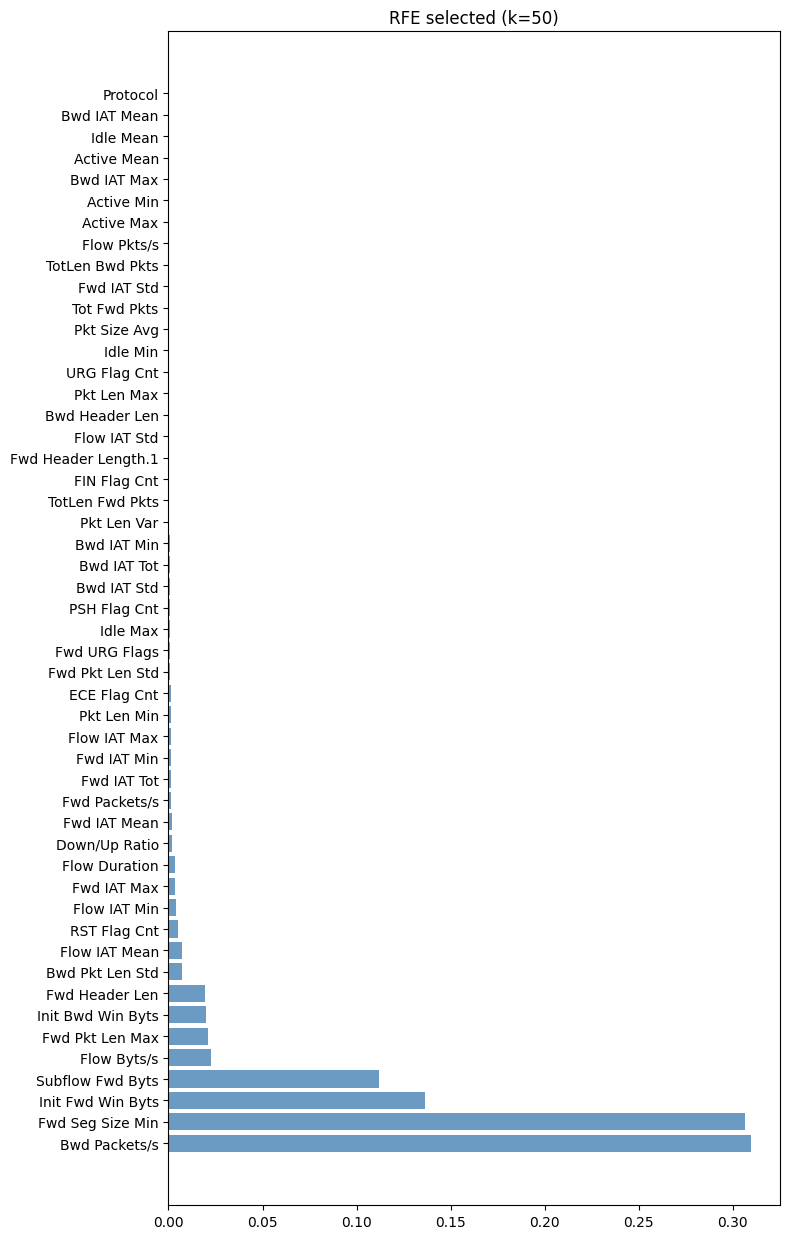

=== RFE k=50 Features (by importance) ===
   1. Bwd Packets/s                                 importance=0.3097
   2. Fwd Seg Size Min                              importance=0.3065
   3. Init Fwd Win Byts                             importance=0.1364
   4. Subflow Fwd Byts                              importance=0.1121
   5. Flow Byts/s                                   importance=0.0224
   6. Fwd Pkt Len Max                               importance=0.0210
   7. Init Bwd Win Byts                             importance=0.0200
   8. Fwd Header Len                                importance=0.0196
   9. Bwd Pkt Len Std                               importance=0.0074
  10. Flow IAT Mean                                 importance=0.0073
  11. RST Flag Cnt                                  importance=0.0052
  12. Flow IAT Min                                  importance=0.0038
  13. Fwd IAT Max                                   importance=0.0037
  14. Flow Duration                             

In [11]:

# Feature ranking (RFE best_k)
best_rfe = RFE(estimator=DecisionTreeClassifier(max_depth=10, min_samples_split=10,
               min_samples_leaf=4, random_state=42), n_features_to_select=best_k, step=140)
best_rfe.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': best_rfe.ranking_,
    'Selected': best_rfe.support_
})
ranking_df['Importance'] = 0.0
ranking_df.loc[ranking_df['Selected'], 'Importance'] = best_rfe.estimator_.feature_importances_

selected_df = (
    ranking_df[ranking_df['Selected']]
    .sort_values('Importance', ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, max(4, best_k * 0.25)))
ax.barh(selected_df['Feature'], selected_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title(f'RFE selected (k={best_k})'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Reuse best_rfe for cross-dataset validation (no re-training) ──────────────
import pickle

rfe_features = X_train.columns[best_rfe.support_].tolist()
dt_rfe = DecisionTreeClassifier(max_depth=20, min_samples_split=10, min_samples_leaf=4,
                                 random_state=42, class_weight='balanced')
dt_rfe.fit(X_train[rfe_features], y_train)

rfe_sorted = pd.Series(best_rfe.estimator_.feature_importances_,
                        index=rfe_features).sort_values(ascending=False)

print(f"=== RFE k={best_k} Features (by importance) ===")
for i, (feat, imp) in enumerate(rfe_sorted.items(), 1):
    print(f"  {i:2d}. {feat:<45} importance={imp:.4f}")

with open('dt_rfe20_model.pkl', 'wb') as f: pickle.dump(dt_rfe, f)
with open('rfe20_selected_features.pkl', 'wb') as f: pickle.dump(rfe_features, f)


## 11. RFE Feature Ranking and Final Model

Re-fits RFE with `best_k` to obtain stable feature importance values (derived from the fitted DT's `feature_importances_`). A horizontal bar chart displays the selected features sorted by importance. The final model and feature list are saved to disk.

In [12]:

# ── Classification report ─────────────────────────────────────────────────────
y_test_pred = dt_rfe.predict(X_test[rfe_features])
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.8792    0.5771    0.6968     10000
  BruteForce     0.9989    0.9995    0.9992     10168
        DDoS     0.9966    0.9992    0.9979     10000
         DoS     0.9993    0.9978    0.9986     12198
Infiltration     0.4991    0.8408    0.6264      5000

    accuracy                         0.8931     47366
   macro avg     0.8746    0.8829    0.8638     47366
weighted avg     0.9205    0.8931    0.8956     47366



## 12. Classification Report — RFE Model

Prints per-class precision, recall, F1-score, and support for the Decision Tree trained on the `best_k` RFE-selected features, evaluated on the held-out test set.

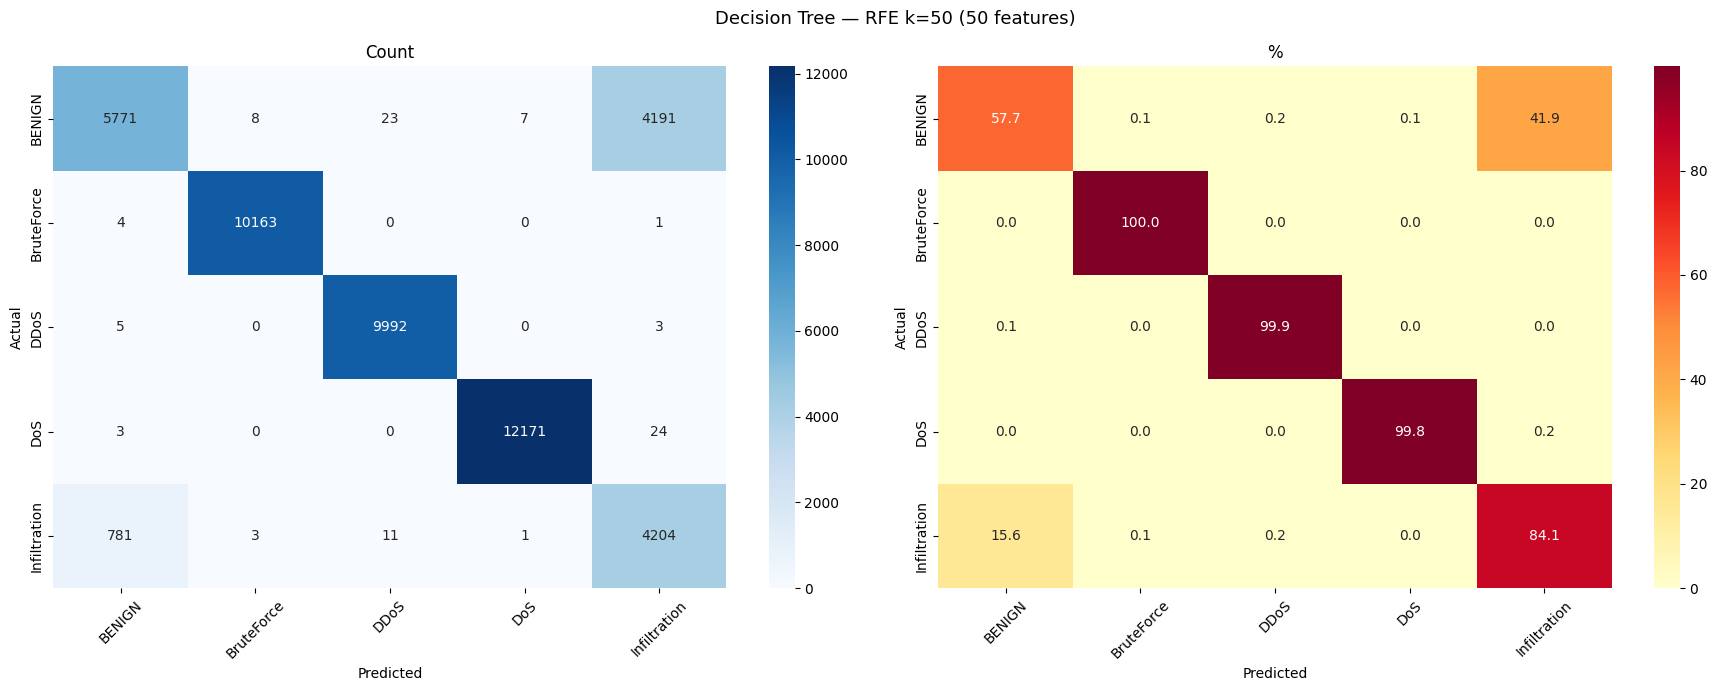

In [13]:

# Confusion matrix — RFE model
cm = confusion_matrix(y_test, dt_rfe.predict(X_test[rfe_features]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Count'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual'); ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('%'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual'); ax2.tick_params(axis='x', rotation=45)

plt.suptitle(f'Decision Tree — RFE k={best_k} ({best_k} features)', fontsize=13)
plt.tight_layout(); plt.show()


## 13. Confusion Matrix — RFE Model

Side-by-side heatmaps showing the absolute count (left) and row-normalised percentage (right) for each true vs. predicted class pair.

---

## Cross-Dataset Evaluation (CIC-IDS 2017)

Evaluates the 2018-trained model against CIC-IDS 2017 data to measure generalisation across datasets.

- **Method 1 — Cross-test:** apply the 2018-trained Decision Tree directly to CIC-2017 using only the features that appear in both datasets (no retraining)

In [14]:
# Load CIC-2017 cross-test dataset (natural distribution)
CIC17_PATH = "../../../../dataset/cicids2017_sample_1M_natural_standardized.csv"
df17_raw = pd.read_csv(CIC17_PATH)
print(f"Shape: {df17_raw.shape}")
print(df17_raw['Label'].value_counts())


Shape: (864031, 79)
Label
BENIGN                        640639
DoS Hulk                      130108
DDoS                           72103
DoS GoldenEye                   5711
FTP-Patator                     4456
SSH-Patator                     3400
DoS slowloris                   3275
DoS Slowhttptest                3058
Web Attack � Brute Force         868
Web Attack � XSS                 361
Infiltration                      36
Heartbleed                        10
Web Attack � Sql Injection         6
Name: count, dtype: int64


## 14. Load CIC-IDS 2017

Loads the CIC-IDS 2017 dataset (1 M rows, natural class distribution) from CSV. The raw label distribution is printed before any grouping.

In [15]:
attack_group_mapping_17 = {
    # # BENIGN
    'BENIGN': 'BENIGN',

    # DoS / DDoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    
    'DDoS': 'DDoS',

    # Brute Force
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    
    'Web Attack � XSS': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',

    'Heartbleed': 'Infiltration',
    'Infiltration': 'Infiltration',
}

df17 = df17_raw.copy()
df17['Label'] = df17['Label'].map(attack_group_mapping_17)
df17.dropna(subset=['Label'], inplace=True)

for g, cnt in df17['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df17)*100:.2f}%)")


  BENIGN                  640,639  (74.43%)
  DoS                     138,877  (16.13%)
  DDoS                     72,103  (8.38%)
  BruteForce                9,085  (1.06%)
  Infiltration                 46  (0.01%)


## 15. Group CIC-IDS 2017 Attack Labels

Applies the same label grouping strategy used for CIC-IDS 2018 so that both datasets share a common set of class names for cross-dataset comparison.

In [16]:
# Preprocess 2017 (same pipeline as 2018)
df17_proc = df17.copy()
df17_proc.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df17_proc.select_dtypes(include=[np.number]).columns:
    if df17_proc[col].isnull().sum() > 0:
        df17_proc[col].fillna(df17_proc[col].median(), inplace=True)

keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop_17 = [c for c in df17_proc.columns if any(k in c.lower() for k in keywords)]
df17_proc.drop(columns=cols_to_drop_17, inplace=True, errors='ignore')
print(f"Shape: {df17_proc.shape}  |  NaN: {df17_proc.isnull().sum().sum()}")


Shape: (860750, 78)  |  NaN: 0


/tmp/ipykernel_57407/2689547596.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df17_proc[col].fillna(df17_proc[col].median(), inplace=True)
/tmp/ipykernel_57407/2689547596.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

## 16. Preprocess CIC-IDS 2017

Applies the same cleaning pipeline to the 2017 data: replace ±inf → NaN, fill with median, and drop identifier columns. This ensures feature compatibility with the 2018-trained model.

In [17]:

# Method 1: Cross-test — shared features only (no zero-fill)
shared_features = [f for f in rfe_features if f in df17_proc.columns]
missing_in_17 = [f for f in rfe_features if f not in df17_proc.columns]

print(f"RFE k={best_k}: {len(rfe_features)} features  |  Shared with CIC-2017: {len(shared_features)}  |  Missing: {len(missing_in_17)}")
if missing_in_17:
    print(f"  Missing features: {missing_in_17}")

X17 = df17_proc[shared_features]
y17_labels = df17_proc['Label']

known_classes = set(le.classes_)
mask_known = y17_labels.isin(known_classes)
X17 = X17[mask_known]
y17_labels = y17_labels[mask_known]
y17 = le.transform(y17_labels)

DT_Shared = DecisionTreeClassifier(max_depth=20, min_samples_split=10, min_samples_leaf=4,
                                    random_state=42, class_weight='balanced')
DT_Shared.fit(X_train[shared_features], y_train)
y17_pred = DT_Shared.predict(X17)
acc_src  = accuracy_score(y_test, DT_Shared.predict(X_test[shared_features]))

acc17 = accuracy_score(y17, y17_pred)
print(f"\nCIC-2018 (source): {acc_src*100:.2f}%")
print(f"CIC-2017 (target): {acc17*100:.2f}%  |  Drop: {(acc_src-acc17)*100:.2f}%")
print()
present_indices = sorted(set(y17))
print(classification_report(y17, y17_pred, labels=present_indices,
                             target_names=le.inverse_transform(present_indices),
                             digits=4, zero_division=0))


RFE k=50: 50 features  |  Shared with CIC-2017: 49  |  Missing: 1
  Missing features: ['Protocol']



CIC-2018 (source): 89.30%
CIC-2017 (target): 34.36%  |  Drop: 54.94%

              precision    recall  f1-score   support

      BENIGN     0.7842    0.3722    0.5048    640639
  BruteForce     0.0052    0.0185    0.0081      9085
        DDoS     0.0035    0.0001    0.0003     72103
         DoS     0.3669    0.4114    0.3879    138877
Infiltration     0.0000    0.1739    0.0000        46

    accuracy                         0.3436    860750
   macro avg     0.2320    0.1952    0.1802    860750
weighted avg     0.6432    0.3436    0.4384    860750



## 17. Method 1 — Cross-Test Results (CIC-IDS 2017)

The Decision Tree trained on CIC-IDS 2018 was tested against CIC-IDS 2017 using only the shared RFE-selected features. The accuracy drop from source to target indicates the degree of domain shift between the two datasets.